Loaded CSV:
    Modulation  Data_Aided    CPR       BER       SER        SNR       EVM  \
0           16        True    bps  0.000197  0.000789  19.456561  0.011383   
1           16        True  ddpll  0.000217  0.000867  19.274866  0.011865   
2           16       False    bps  0.001261  0.004956  18.637182  0.013686   
3           16       False  ddpll  0.001308  0.005156  18.471771  0.014213   
4           64        True    bps  0.009244  0.051018  20.295021  0.009566   
5           64        True  ddpll  0.010171  0.056577  20.115031  0.009959   
6           64       False    bps  0.069221  0.370434  14.815542  0.032753   
7           64       False  ddpll  0.080498  0.420676  14.061708  0.038893   
8          256        True    bps  0.079088  0.514700  18.890958  0.013175   
9          256        True  ddpll  0.118875  0.656500  15.850804  0.026126   
10         256       False    bps  0.148456  0.779025  14.889382  0.032280   
11         256       False  ddpll  0.168159  0.81462

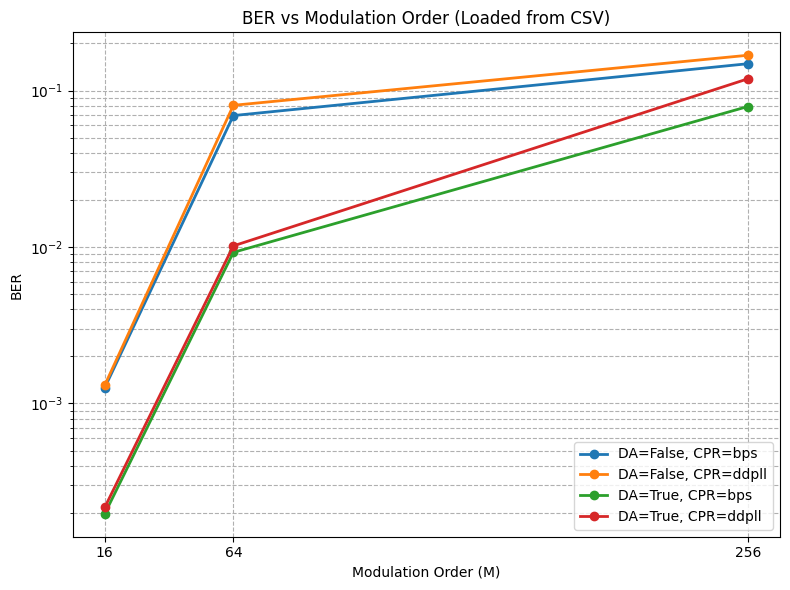

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load the CSV file
# ---------------------------------------------------------
csv_path = "results_BER_vs_Modulation.csv"   # <-- change name if needed
df = pd.read_csv(csv_path)

print("Loaded CSV:")
print(df)
print()

# ---------------------------------------------------------
# 2. Plot BER vs Modulation Order
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

# Group by DA and CPR like before
for (data_aided, cpr_mode), subset in df.groupby(["Data_Aided", "CPR"]):

    # Sort by Modulation for clean curves
    subset = subset.sort_values("Modulation")

    label = f"DA={data_aided}, CPR={cpr_mode}"

    plt.semilogy(
        subset["Modulation"],
        subset["BER"],
        marker='o',
        linewidth=2,
        label=label
    )

# X-axis ticks for M = 16, 64, 256
plt.xticks([16, 64, 256], ["16", "64", "256"])

plt.grid(True, which='both', linestyle='--')
plt.xlabel("Modulation Order (M)")
plt.ylabel("BER")
plt.title("BER vs Modulation Order (Loaded from CSV)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. List your CSV files here
# ---------------------------------------------------------
csv_files = [
    "results_BER_vs_Modulation.csv",
    "results_case2.csv",
    "results_case3.csv",
    # add more files...
]

# ---------------------------------------------------------
# 2. Load all CSVs into one big DataFrame
# ---------------------------------------------------------
all_data = []

for f in csv_files:
    df = pd.read_csv(f)
    df["source"] = os.path.splitext(os.path.basename(f))[0]  # label with filename
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

print("Loaded files:", csv_files)
print(df_all.head())


# ---------------------------------------------------------
# 3. Plot BER vs Modulation for all files
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))

# Group by filename + DA flag + CPR mode
for (src, data_aided, cpr_mode), subset in df_all.groupby(["source", "Data_Aided", "CPR"]):

    subset = subset.sort_values("Modulation")

    label = f"{src} | DA={data_aided}, CPR={cpr_mode}"

    plt.semilogy(
        subset["Modulation"],
        subset["BER"],
        marker='o',
        linewidth=2,
        label=label
    )

plt.xticks([16, 64, 256], ["16", "64", "256"])
plt.grid(True, which='both', linestyle='--')

plt.xlabel("Modulation Order (M)")
plt.ylabel("BER")
plt.title("BER vs Modulation (Multiple CSV Files)")
plt.legend()
plt.tight_layout()
plt.show()